# Stage 7 — Execution on the Noise-Emulated Backend

### Part of: *Quantum Circuit-Based Adaptation for Credit Risk Analysis*

**Previous:** ← `06_hardware_retuning.ipynb`
**Next:** → `08_classical_postprocessing.ipynb`

---

Stage 6 decided *which angles* to send to the device. This stage is the actual experiment: the full GCI circuit is executed with those angles on the noise-emulated backend, with thousands of shots and many independent repetitions, and two standard error-mitigation techniques are benchmarked on top — something the base paper leaves as future work.

## 1. What Is "Execution" Here? (General Overview)

A quantum circuit never returns its probability distribution directly. Each execution ("shot") ends in a measurement that collapses the register to **one** bitstring; the distribution is only visible as the histogram of many shots. Two kinds of uncertainty therefore sit on every result:

- **Statistical (shot) noise** — with $N$ shots a probability $p$ is estimated with standard error $\sqrt{p(1-p)/N}$ (≈0.3 % for $p=0.25$, $N=20\,000$). It shrinks with more shots and is measured here by repeating each experiment 20 times.
- **Systematic hardware error** — gate noise, readout bias, drift. More shots do *not* remove it; only better angles (Stage 6) or error mitigation (this stage) can.

The base paper ran its circuits on the Contralto-D chip and repeated its measurements 100 times to get error bars (Sec. IV-A). Here the chip is Qiskit's `AerSimulator` with the noise model of Stage 6 (`src/device.py`).

## 2. Why We Do This

1. **It produces the measured distributions everything downstream is judged on.** Stage 8 turns them into loss PDFs/CDFs, Stage 9 into VaR and fidelity numbers.
2. **It closes a gap the paper leaves open.** The paper applies no readout mitigation (Sec. VI: "no readout error mitigation technique has been applied") and only *discusses* ZNE (Sec. V). Measuring what each adds, on top of angle retuning, is novelty point 3 in `00_overview.ipynb` §5.
3. **Error bars turn "looks better" into "is better".** 20 independent repetitions per variant make the comparison between uncalibrated / 6A / 6B statistically meaningful.

## 3. Where This Fits in the Project Pipeline

This is **Stage 7 of 9**.

- **Input:** `results/stage06_retuning.json` — the uncalibrated, 6A and 6B commanded angles for the 2- and 3-qubit-register GCI circuits.
- **Output:** `results/stage07_execution.json` — for every variant below, the mean and standard deviation of the measured distribution over 20 repetitions of 20 000 shots, plus every individual repetition.

| Variant | Angles | Correction |
|---|---|---|
| `ideal_noiseless` | Stage 4 | none — exact noiseless reference (the paper's Fig. 10a) |
| `noisy_uncalibrated` | Stage 4 | none — raw counts |
| `uncalibrated_REM` | Stage 4 | readout-error mitigation only |
| `6A_grid_REM` | Stage 6A | readout-error mitigation |
| `6B_auto_REM` | Stage 6B | readout-error mitigation — **the deployed pipeline** |
| `6B_auto_REM_ZNE` | Stage 6B | readout mitigation + zero-noise extrapolation |

## 4. Key Concepts

### 4.1 Readout-error mitigation (REM)

Prepare each of the $2^{m}$ basis states $|s\rangle$ on the measured qubits, measure, and record the **assignment matrix**

$$
A_{is} = P(\text{read } i \mid \text{prepared } s).
$$

A measured distribution satisfies $\mathbf{m} \approx A\,\mathbf{p}_{\text{true}}$, so the true one is recovered by solving
$\min_{\mathbf{p}\ge 0} \lVert A\mathbf{p} - \mathbf{m}\rVert_2$ (non-negative least squares) and renormalising. NNLS rather than $A^{-1}\mathbf{m}$ keeps the result a valid probability distribution. The calibration costs $2^m$ extra circuits (8 or 16 here) and is done once per device.

### 4.2 Zero-noise extrapolation (ZNE)

**Global unitary folding** replaces the circuit $U$ by $U\,(U^\dagger U)^k$. Logically nothing changes ($U^\dagger U = I$), but the hardware now executes $\lambda = 2k+1$ times as many noisy gates, so the noise is amplified by a known factor. Measuring at $\lambda = 1, 3, 5$ and fitting each outcome probability linearly,

$$
p_i(\lambda) \approx a_i + b_i\,\lambda \quad\Longrightarrow\quad p_i(0) \approx a_i ,
$$

estimates what an error-free device would return. Folding is applied to the already-transpiled hardware circuit, so the folded circuits run on exactly the same physical qubits. Each folded result is readout-mitigated first, then extrapolated.

**What ZNE can and cannot fix.** Folding amplifies *incoherent* gate noise (depolarizing). Coherent drift is also amplified, but not linearly — which is one reason why the coherent part is fixed by retuning (Stage 6) and not left to ZNE.

## 5. Implementation

### 5.1 Loading the calibrated angles from Stage 6

In [1]:
import os, sys, json
sys.path.insert(0, os.path.abspath("."))
import numpy as np
import matplotlib.pyplot as plt

from src import config as C
from src.device import NoisyDevice
from src.stages import execute_variants, VARIANT_DESCRIPTIONS, config_snapshot
from src.mitigation import assignment_matrix, fold_circuit, apply_readout_mitigation, zne_extrapolate
from src.metrics import hellinger_fidelity
from src.pipeline_io import load_stage_output, save_json, save_fig

BLUE, RED, GREEN, GREY, ORANGE, PURPLE = "#1f4e8c", "#c0392b", "#27ae60", "#7f8c8d", "#e67e22", "#8e44ad"
COLORS = {"ideal_noiseless": BLUE, "noisy_uncalibrated": RED, "uncalibrated_REM": "#f1948a",
          "6A_grid_REM": ORANGE, "6B_auto_REM": GREEN, "6B_auto_REM_ZNE": PURPLE}

s6 = load_stage_output("stage06_retuning.json")
for n in C.REGISTER_SIZES:
    print(f"{n}-qubit register -- commanded angles from Stage 6 (deg):")
    for k, v in s6[f"{n}_qubit"]["calibrated_parameters"].items():
        print(f"   {k:13s}: {np.round(np.rad2deg(v), 2)}")
print(f"\nShots per execution: {C.SHOTS_EXECUTION:,}   independent repetitions: {C.N_REPEATS}")

2-qubit register -- commanded angles from Stage 6 (deg):
   uncalibrated : [ 90.   195.35  40.42  -6.93]
   grid_6A      : [ 90.   234.    40.42  -1.43]
   auto_6B      : [ 70.4  224.51  50.85  -6.82]
3-qubit register -- commanded angles from Stage 6 (deg):
   uncalibrated : [ 89.99  55.04 131.01  40.42  -2.97]
   grid_6A      : [ 89.99 256.5  198.    52.42  -4.22]
   auto_6B      : [115.01  34.37 109.92  55.32  -5.28]

Shots per execution: 20,000   independent repetitions: 20


### 5.2 Readout calibration — the assignment matrix

A perfect readout would give the identity matrix. The diagonal shows how often each bitstring is read correctly; states with more 1s are read worse, because relaxation during the readout pulse turns $1 \to 0$ more often than the reverse.

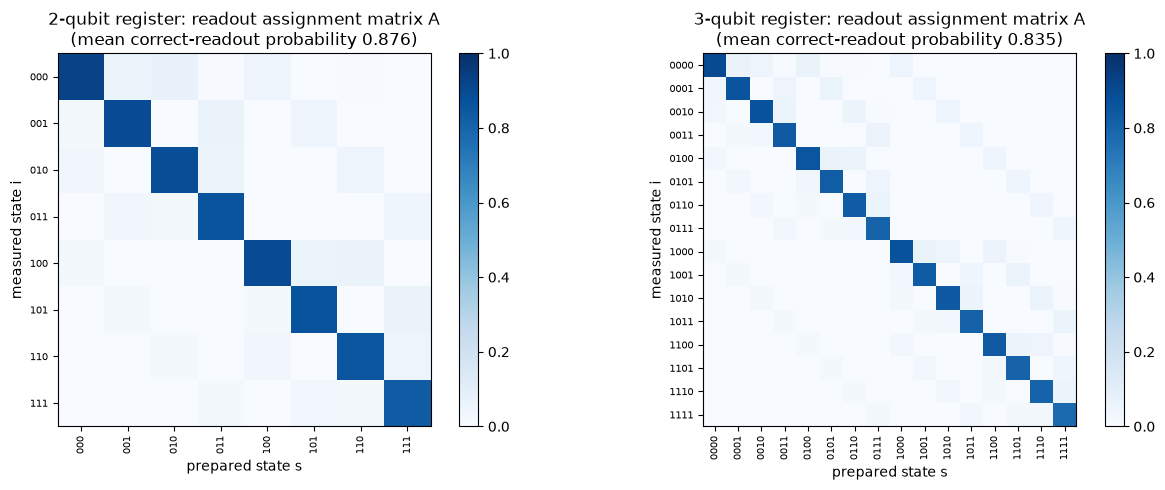

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
A_mats = {}
for ax, n in zip(axes, C.REGISTER_SIZES):
    dev = NoisyDevice(n, "gci")
    A = assignment_matrix(dev)
    A_mats[n] = A
    im = ax.imshow(A, cmap="Blues", vmin=0, vmax=1)
    labels = [format(i, f"0{n+1}b") for i in range(2 ** (n + 1))]
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel("prepared state s"); ax.set_ylabel("measured state i")
    ax.set_title(f"{n}-qubit register: readout assignment matrix A\n"
                 f"(mean correct-readout probability {np.mean(np.diag(A)):.3f})")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); save_fig(fig, "stage07_assignment_matrices.png"); plt.show()

### 5.3 How ZNE works on one circuit

Before running everything, a look inside ZNE for the 2-qubit-register circuit with the 6B angles: the folded circuit at $\lambda=3$ has three times the two-qubit gates; each outcome probability drifts roughly linearly with $\lambda$; the fit is extrapolated back to $\lambda=0$.

lambda = 1:  depth =   32,  CZ gates =   8
lambda = 3:  depth =  134,  CZ gates =  24
lambda = 5:  depth =  236,  CZ gates =  40


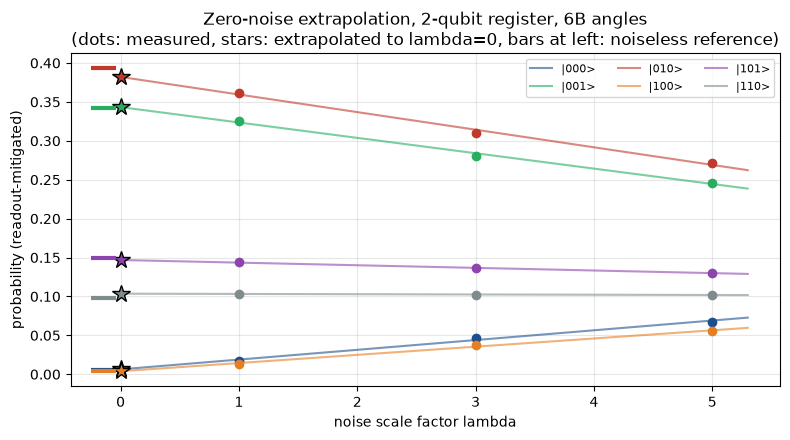

F_H at lambda=1: 0.9827   after ZNE: 0.9991


In [3]:
n = 2
dev = NoisyDevice(n, "gci")
x6b = np.array(s6[f"{n}_qubit"]["calibrated_parameters"]["auto_6B"])
bound = dev.bound_circuit(x6b)
for lam in C.ZNE_SCALE_FACTORS:
    f = fold_circuit(bound, lam)
    print(f"lambda = {lam}:  depth = {f.depth():4d},  CZ gates = {f.count_ops().get('cz', 0):3d}")

ref = dev.ideal_probs(np.array(s6[f"{n}_qubit"]["calibrated_parameters"]["uncalibrated"]))
probs = [apply_readout_mitigation(dev.run_circuit(fold_circuit(bound, lam), 50000, seed=7), A_mats[n])
         for lam in C.ZNE_SCALE_FACTORS]
p0 = zne_extrapolate(C.ZNE_SCALE_FACTORS, probs)

fig, ax = plt.subplots(figsize=(8, 4.5))
lams = np.array(C.ZNE_SCALE_FACTORS)
grid = np.linspace(0, 5.3, 50)
for i, c in zip([0, 1, 2, 4, 5, 6], [BLUE, GREEN, RED, ORANGE, PURPLE, GREY]):
    y = [p[i] for p in probs]
    a, b = np.polyfit(lams, y, 1)
    ax.plot(lams, y, "o", color=c)
    ax.plot(grid, a * grid + b, "-", color=c, alpha=0.6, label=f"|{i:03b}>")
    ax.plot(0, p0[i], "*", color=c, ms=13, mec="k")
    ax.plot(-0.15, ref[i], "_", color=c, ms=18, mew=3)
ax.set_xlabel("noise scale factor lambda"); ax.set_ylabel("probability (readout-mitigated)")
ax.set_title("Zero-noise extrapolation, 2-qubit register, 6B angles\n"
             "(dots: measured, stars: extrapolated to lambda=0, bars at left: noiseless reference)")
ax.legend(fontsize=8, ncol=3); ax.grid(alpha=0.3); plt.tight_layout()
save_fig(fig, "stage07_zne_extrapolation.png"); plt.show()
print(f"F_H at lambda=1: {hellinger_fidelity(probs[0], ref):.4f}   after ZNE: {hellinger_fidelity(p0, ref):.4f}")

### 5.4 Running every variant — 20 repetitions × 20 000 shots

In [4]:
execution = {}
for n in C.REGISTER_SIZES:
    execution[n] = execute_variants(n, s6[f"{n}_qubit"]["calibrated_parameters"], verbose=True)
    print()

  [2q] ideal_noiseless      F_H vs ideal = 1.0000 +/- 0.0000
  [2q] noisy_uncalibrated   F_H vs ideal = 0.8794 +/- 0.0026
  [2q] uncalibrated_REM     F_H vs ideal = 0.9218 +/- 0.0027
  [2q] 6A_grid_REM          F_H vs ideal = 0.9391 +/- 0.0022
  [2q] 6B_auto_REM          F_H vs ideal = 0.9819 +/- 0.0016
  [2q] 6B_auto_REM_ZNE      F_H vs ideal = 0.9983 +/- 0.0007



  [3q] ideal_noiseless      F_H vs ideal = 1.0000 +/- 0.0000
  [3q] noisy_uncalibrated   F_H vs ideal = 0.9189 +/- 0.0018
  [3q] uncalibrated_REM     F_H vs ideal = 0.9087 +/- 0.0025
  [3q] 6A_grid_REM          F_H vs ideal = 0.9564 +/- 0.0015
  [3q] 6B_auto_REM          F_H vs ideal = 0.9946 +/- 0.0007
  [3q] 6B_auto_REM_ZNE      F_H vs ideal = 0.9958 +/- 0.0008



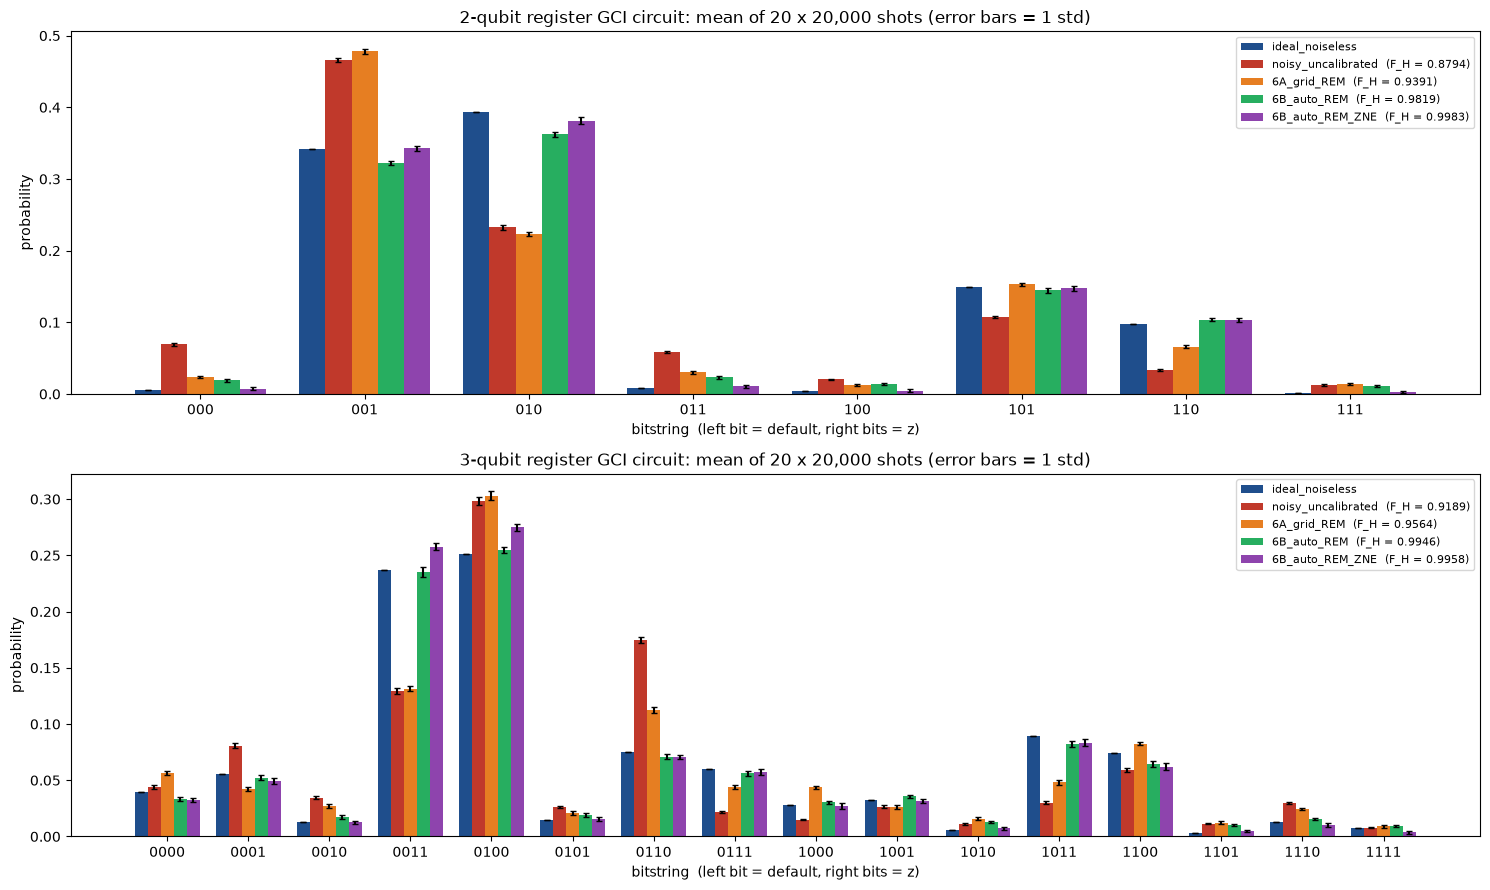

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))
show = ["ideal_noiseless", "noisy_uncalibrated", "6A_grid_REM", "6B_auto_REM", "6B_auto_REM_ZNE"]
for ax, n in zip(axes, C.REGISTER_SIZES):
    V = execution[n]["variants"]
    k = np.arange(2 ** (n + 1)); w = 0.8 / len(show)
    for i, key in enumerate(show):
        m, s = np.array(V[key]["mean_probs"]), np.array(V[key]["std_probs"])
        lab = key if key == "ideal_noiseless" else f"{key}  (F_H = {V[key]['fidelity_vs_ideal_mean']:.4f})"
        ax.bar(k + (i - len(show) / 2 + 0.5) * w, m, w, yerr=s, capsize=2, color=COLORS[key], label=lab)
    ax.set_xticks(k); ax.set_xticklabels([format(i, f"0{n+1}b") for i in k])
    ax.set_ylabel("probability"); ax.set_xlabel("bitstring  (left bit = default, right bits = z)")
    ax.set_title(f"{n}-qubit register GCI circuit: mean of {C.N_REPEATS} x {C.SHOTS_EXECUTION:,} shots (error bars = 1 std)")
    ax.legend(fontsize=8)
plt.tight_layout(); save_fig(fig, "stage07_execution_distributions.png"); plt.show()

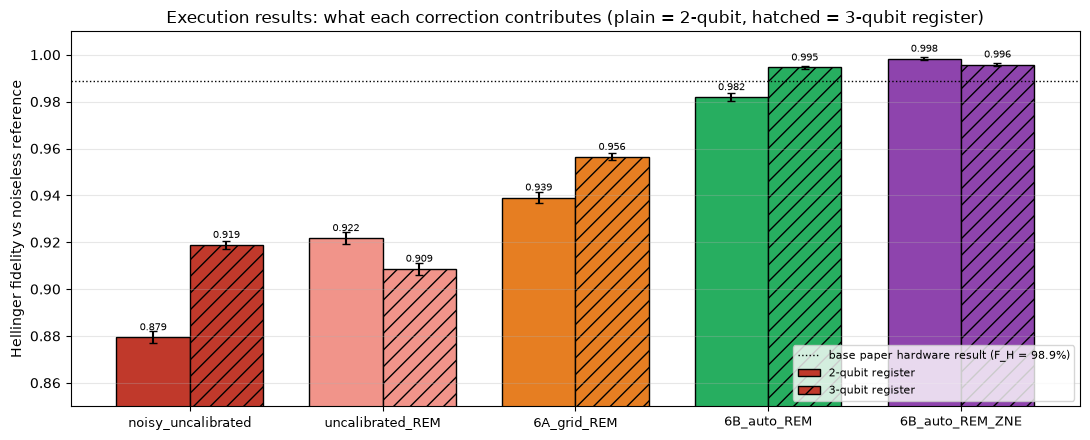

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
keys = [k for k in VARIANT_DESCRIPTIONS if k != "ideal_noiseless"]
x = np.arange(len(keys)); w = 0.38
for j, n in enumerate(C.REGISTER_SIZES):
    V = execution[n]["variants"]
    m = [V[k]["fidelity_vs_ideal_mean"] for k in keys]
    s = [V[k]["fidelity_vs_ideal_std"] for k in keys]
    bars = ax.bar(x + (j - 0.5) * w, m, w, yerr=s, capsize=3, color=[COLORS[k] for k in keys],
                  edgecolor="k", hatch="" if n == 2 else "//", label=f"{n}-qubit register")
    for xi, v in zip(x + (j - 0.5) * w, m):
        ax.text(xi, v + 0.003, f"{v:.3f}", ha="center", fontsize=7.5)
ax.axhline(0.989, color="k", ls=":", lw=1, label="base paper hardware result (F_H = 98.9%)")
ax.set_xticks(x); ax.set_xticklabels(keys, fontsize=9)
ax.set_ylim(0.85, 1.01); ax.set_ylabel("Hellinger fidelity vs noiseless reference")
ax.set_title("Execution results: what each correction contributes (plain = 2-qubit, hatched = 3-qubit register)")
ax.legend(fontsize=8, loc="lower right"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); save_fig(fig, "stage07_fidelity_by_variant.png"); plt.show()

### 5.5 Reading the result

- **Readout mitigation alone does not rescue the uncalibrated circuit** — the coherent drift is still there.
- **Retuning is what moves the needle**, and the automated 6B angles clearly beat the paper-style 6A grid sweep for both register sizes.
- **ZNE on top** gives a further gain for the 2-qubit register, and a small one for the 3-qubit register. ZNE is not free: it triples and quintuples the gate count, so it multiplies the execution cost by $1+3+5 = 9$ in gate-time. Part of the depolarizing distortion was already absorbed by the retuned angles, which limits how much ZNE can still add.

### 5.6 Saving the execution results for Stage 8

In [7]:
out = {"config": config_snapshot()}
for n in C.REGISTER_SIZES:
    out[f"{n}_qubit"] = execution[n]
path = save_json(out, "stage07_execution.json")
print(f"Saved -> {path}")
print("\nSummary (Hellinger fidelity vs noiseless reference, mean +/- std over repetitions):")
for n in C.REGISTER_SIZES:
    for k, v in execution[n]["variants"].items():
        print(f"  {n}q  {k:20s} {v['fidelity_vs_ideal_mean']:.4f} +/- {v['fidelity_vs_ideal_std']:.4f}")

Saved -> /home/muthuraam/quantum-credit-risk-vqc/results/stage07_execution.json

Summary (Hellinger fidelity vs noiseless reference, mean +/- std over repetitions):
  2q  ideal_noiseless      1.0000 +/- 0.0000
  2q  noisy_uncalibrated   0.8794 +/- 0.0026
  2q  uncalibrated_REM     0.9218 +/- 0.0027
  2q  6A_grid_REM          0.9391 +/- 0.0022
  2q  6B_auto_REM          0.9819 +/- 0.0016
  2q  6B_auto_REM_ZNE      0.9983 +/- 0.0007
  3q  ideal_noiseless      1.0000 +/- 0.0000
  3q  noisy_uncalibrated   0.9189 +/- 0.0018
  3q  uncalibrated_REM     0.9087 +/- 0.0025
  3q  6A_grid_REM          0.9564 +/- 0.0015
  3q  6B_auto_REM          0.9946 +/- 0.0007
  3q  6B_auto_REM_ZNE      0.9958 +/- 0.0008


## 6. What This Stage Produces

1. **Measured output distributions** of the full GCI circuit for six variants and both register sizes — 20 repetitions × 20 000 shots each, with error bars.
2. **A readout-error-mitigation implementation** (assignment matrix + NNLS) and a **zero-noise-extrapolation implementation** (global folding on the transpiled circuit + linear extrapolation), in `src/mitigation.py`.
3. **A quantitative answer to "what does each correction buy?"** — retuning fixes the coherent part, readout mitigation the readout part, ZNE part of the remaining gate noise.
4. **`results/stage07_execution.json`** — the input to Stage 8.

## 7. What's Next

**Stage 8 — Classical post-processing (`08_classical_postprocessing.ipynb`):** every measured distribution is decomposed, exactly as in the base paper, into default indicators and latent-factor values, and turned into a portfolio-loss PDF and CDF.

---
*Next: → `08_classical_postprocessing.ipynb`*